In [1]:
!pip install -q --upgrade yfinance

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

print("Environment ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 2.3 MB/s eta 0:00:00
Environment ready.


**Configuration**

In [2]:
CONFIG = {
    # Portfolio definition -- replace with your own tickers/weights.
    # Weights must sum to 1.0; the engine will normalize and warn if they don't.
    "tickers": ["AAPL", "MSFT", "JPM", "XOM", "TLT"],
    "weights": [0.25, 0.25, 0.20, 0.15, 0.15],

    "start_date": "2018-01-01",
    "end_date": None,  # None = up to today

    "portfolio_value": 10_000_000,   # USD notional the VaR/CVaR figures are scaled to

    "confidence_levels": [0.95, 0.99],
    "horizon_days": 1,               # 1-day VaR is the industry-standard reporting horizon

    "n_simulations": 50_000,
    "random_seed": 42,
    "innovation_dist": "normal",     # "normal" or "t" (fatter tails)
    "t_dist_df": 5,                  # degrees of freedom if innovation_dist == "t"

    "backtest_window": 250,          # ~1 trading year of trailing data per backtest step
    "backtest_confidence": 0.95,
}

# normalize weights defensively in case they don't sum to exactly 1.0
_w = np.array(CONFIG["weights"], dtype=float)
if not np.isclose(_w.sum(), 1.0, atol=1e-6):
    print(f"WARNING: weights summed to {_w.sum():.4f}, normalizing to 1.0")
    _w = _w / _w.sum()
CONFIG["weights"] = _w.tolist()

if len(CONFIG["tickers"]) != len(CONFIG["weights"]):
    raise ValueError("CONFIG['tickers'] and CONFIG['weights'] must be the same length.")

print(f"Portfolio: {dict(zip(CONFIG['tickers'], CONFIG['weights']))}")
print(f"Notional: ${CONFIG['portfolio_value']:,.0f}")


Portfolio: {'AAPL': 0.25, 'MSFT': 0.25, 'JPM': 0.2, 'XOM': 0.15, 'TLT': 0.15}
Notional: $10,000,000


**Data Collection pipeline**

In [3]:
def fetch_price_data(tickers, start_date, end_date=None, max_retries=3, retry_delay=1.5):
    """
    Download daily adjusted close prices for each ticker individually from Yahoo Finance.

    Downloading one ticker at a time (rather than a batch yf.download call) avoids the
    column-structure inconsistencies yfinance has between single- and multi-ticker
    requests, and lets us isolate exactly which ticker failed if something goes wrong.

    Returns
    -------
    price_df : pd.DataFrame
        Adjusted close prices, columns = tickers, index = trading dates.
    failed_tickers : list[str]
        Tickers that could not be fetched after all retries.
    """
    all_data = {}
    failed_tickers = []

    for ticker in tickers:
        success = False
        last_error = None
        for attempt in range(1, max_retries + 1):
            try:
                data = yf.download(
                    ticker, start=start_date, end=end_date,
                    auto_adjust=True, progress=False
                )
                if data is None or data.empty:
                    raise ValueError("empty response")
                series = data["Close"]
                if isinstance(series, pd.DataFrame):  # defensive: handle stray MultiIndex
                    series = series.iloc[:, 0]
                if series.dropna().shape[0] < 30:
                    raise ValueError("fewer than 30 valid observations returned")
                all_data[ticker] = series
                success = True
                break
            except Exception as e:
                last_error = e
                if attempt < max_retries:
                    time.sleep(retry_delay)
        if success:
            print(f"  fetched {ticker}: {len(all_data[ticker])} observations")
        else:
            print(f"  FAILED {ticker} after {max_retries} attempts ({last_error})")
            failed_tickers.append(ticker)

    if not all_data:
        raise RuntimeError(
            "Could not fetch data for ANY ticker. Check ticker symbols, date range, "
            "and that this environment has network access to Yahoo Finance."
        )

    price_df = pd.DataFrame(all_data)
    return price_df, failed_tickers


print("Fetching price data...")
price_df, failed_tickers = fetch_price_data(
    CONFIG["tickers"], CONFIG["start_date"], CONFIG["end_date"]
)

if failed_tickers:
    print(f"\nExcluding failed tickers from the portfolio: {failed_tickers}")
    keep_idx = [i for i, t in enumerate(CONFIG["tickers"]) if t not in failed_tickers]
    CONFIG["tickers"] = [CONFIG["tickers"][i] for i in keep_idx]
    w = np.array([CONFIG["weights"][i] for i in keep_idx])
    CONFIG["weights"] = (w / w.sum()).tolist()  # renormalize remaining weights
    print(f"Renormalized portfolio: {dict(zip(CONFIG['tickers'], CONFIG['weights']))}")

price_df = price_df[CONFIG["tickers"]].dropna()
print(f"\nFinal price history: {price_df.shape[0]} trading days x {price_df.shape[1]} assets")
price_df.tail()

Fetching price data...
  fetched AAPL: 2135 observations
  fetched MSFT: 2135 observations
  fetched JPM: 2135 observations
  fetched XOM: 2135 observations
  fetched TLT: 2135 observations

Final price history: 2135 trading days x 5 assets


,AAPL,MSFT,JPM,XOM,TLT
Date,,,,,
2026-06-25,275.149994,352.829987,335.119995,137.550003,87.349998
2026-06-26,283.779999,372.970001,329.049988,136.539993,87.360001
2026-06-29,281.739990,368.570007,329.390015,136.059998,87.449997
2026-06-30,289.359985,373.019989,327.329987,136.720001,86.419998
2026-07-01,294.380005,384.279999,334.070007,136.279999,85.519997


In [4]:
def compute_log_returns(price_df):
    """Convert a price DataFrame to log returns, dropping the first NaN row."""
    log_rets = np.log(price_df / price_df.shift(1))
    n_before = len(log_rets)
    log_rets = log_rets.dropna()
    n_dropped = n_before - len(log_rets)
    if n_dropped > 1:  # more than just the expected first-row NaN
        print(f"WARNING: dropped {n_dropped} rows with missing data (check for halts/gaps).")
    return log_rets

log_returns = compute_log_returns(price_df)
weights = np.array(CONFIG["weights"])

portfolio_returns = pd.Series(log_returns.values @ weights, index=log_returns.index, name="portfolio")

mean_vec = log_returns.mean().values
cov_matrix = log_returns.cov().values
mu_p = portfolio_returns.mean()
sigma_p = portfolio_returns.std()

print(f"Sample period: {log_returns.index[0].date()} to {log_returns.index[-1].date()} "
      f"({len(log_returns)} trading days)")
print(f"Annualized portfolio return: {mu_p * 252:.2%}")
print(f"Annualized portfolio volatility: {sigma_p * np.sqrt(252):.2%}")

Sample period: 2018-01-03 to 2026-07-01 (2134 trading days)
Annualized portfolio return: 15.02%
Annualized portfolio volatility: 18.91%


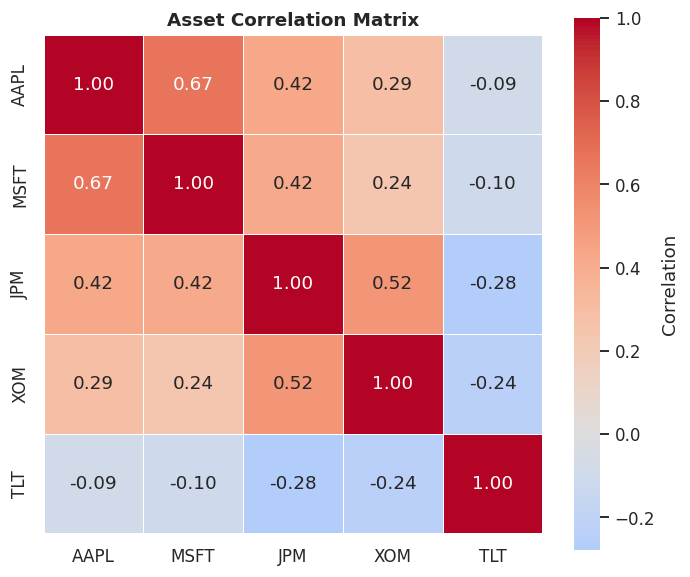

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    log_returns.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, cbar_kws={"label": "Correlation"}, ax=ax
)
ax.set_title("Asset Correlation Matrix")
plt.tight_layout()
plt.show()

In [6]:
def parametric_var_cvar(mean, std, confidence, value, horizon_days=1, dist="normal", t_df=5):
    """
    Closed-form parametric VaR and CVaR (Expected Shortfall) for a single horizon.

    Parameters
    ----------
    mean, std : float
        Daily mean and standard deviation of portfolio returns.
    confidence : float
        e.g. 0.95 for 95% VaR.
    value : float
        Portfolio notional value the result is scaled to.
    dist : {"normal", "t"}
        Return distribution assumption. "t" produces fatter tails for the same std.
    """
    if not (0 < confidence < 1):
        raise ValueError(f"confidence must be in (0, 1), got {confidence}")

    if dist == "normal":
        z = stats.norm.ppf(1 - confidence)
        var_pct = -(mean * horizon_days + z * std * np.sqrt(horizon_days))
        phi_z = stats.norm.pdf(z)
        cvar_pct = -(mean * horizon_days - std * np.sqrt(horizon_days) * phi_z / (1 - confidence))
    elif dist == "t":
        if t_df <= 2:
            raise ValueError("t_df must be > 2 for a finite variance")
        z = stats.t.ppf(1 - confidence, df=t_df)
        scale = std * np.sqrt((t_df - 2) / t_df)  # rescale so variance matches `std`
        var_pct = -(mean * horizon_days + z * scale * np.sqrt(horizon_days))
        pdf_z = stats.t.pdf(z, df=t_df)
        cvar_pct = -(mean * horizon_days - scale * np.sqrt(horizon_days)
                     * (t_df + z**2) / (t_df - 1) * pdf_z / (1 - confidence))
    else:
        raise ValueError("dist must be 'normal' or 't'")

    return var_pct * value, cvar_pct * value


parametric_results = {}
for c in CONFIG["confidence_levels"]:
    var, cvar = parametric_var_cvar(
        mu_p, sigma_p, c, CONFIG["portfolio_value"],
        horizon_days=CONFIG["horizon_days"], dist=CONFIG["innovation_dist"], t_df=CONFIG["t_dist_df"]
    )
    parametric_results[c] = {"VaR": var, "CVaR": cvar}
    print(f"Parametric {int(c*100)}%:  VaR = ${var:,.0f}   CVaR = ${cvar:,.0f}")

Parametric 95%:  VaR = $189,978   CVaR = $239,754
Parametric 99%:  VaR = $271,159   CVaR = $311,525


In [7]:
def historical_var_cvar(returns_series, confidence, value):
    """Empirical VaR/CVaR from the actual historical return distribution."""
    if not (0 < confidence < 1):
        raise ValueError(f"confidence must be in (0, 1), got {confidence}")
    losses = (-returns_series * value).values
    var = np.percentile(losses, confidence * 100)
    tail = losses[losses >= var]
    cvar = tail.mean() if len(tail) > 0 else var
    return var, cvar


historical_results = {}
for c in CONFIG["confidence_levels"]:
    var, cvar = historical_var_cvar(portfolio_returns, c, CONFIG["portfolio_value"])
    historical_results[c] = {"VaR": var, "CVaR": cvar}
    print(f"Historical {int(c*100)}%:  VaR = ${var:,.0f}   CVaR = ${cvar:,.0f}")

Historical 95%:  VaR = $177,410   CVaR = $284,444
Historical 99%:  VaR = $339,006   CVaR = $490,125


In [8]:
class MonteCarloVaREngine:
    """
    Monte Carlo VaR/CVaR engine for a fixed-weight portfolio.

    Simulates `n_sims` correlated asset return paths from a multivariate normal or
    Student-t distribution (built from the supplied covariance matrix via Cholesky
    decomposition), aggregates to portfolio P&L, and reads VaR/CVaR off the tail.
    """

    def __init__(self, mean_vec, cov_matrix, weights, portfolio_value, seed=None):
        self.mean_vec = np.asarray(mean_vec, dtype=float)
        self.cov_matrix = np.asarray(cov_matrix, dtype=float)
        self.weights = np.asarray(weights, dtype=float)
        self.portfolio_value = portfolio_value
        self.rng = np.random.default_rng(seed)
        self.last_sim_pnl = None
        self._validate()

    def _validate(self):
        n = len(self.weights)
        if self.mean_vec.shape[0] != n:
            raise ValueError("mean_vec length must match weights length")
        if self.cov_matrix.shape != (n, n):
            raise ValueError("Covariance matrix shape does not match number of weights")
        if not np.allclose(self.cov_matrix, self.cov_matrix.T, atol=1e-8):
            raise ValueError("Covariance matrix is not symmetric")

    def _cholesky(self):
        try:
            return np.linalg.cholesky(self.cov_matrix)
        except np.linalg.LinAlgError:
            # Covariance matrix isn't strictly positive-definite -- common with short
            # lookback windows or near-collinear assets. Nudge the diagonal slightly
            # rather than failing outright.
            n = len(self.weights)
            adjusted = self.cov_matrix + np.eye(n) * 1e-10
            return np.linalg.cholesky(adjusted)

    def simulate(self, n_sims=50_000, horizon_days=1, dist="normal", t_df=5):
        n = len(self.weights)
        L = self._cholesky()

        if dist == "normal":
            Z = self.rng.standard_normal(size=(n_sims, n))
        elif dist == "t":
            if t_df <= 2:
                raise ValueError("t_df must be > 2 for a finite variance")
            Z = self.rng.standard_t(df=t_df, size=(n_sims, n)) * np.sqrt((t_df - 2) / t_df)
        else:
            raise ValueError("dist must be 'normal' or 't'")

        sim_asset_returns = self.mean_vec * horizon_days + (Z @ L.T) * np.sqrt(horizon_days)
        sim_port_returns = sim_asset_returns @ self.weights
        self.last_sim_pnl = sim_port_returns * self.portfolio_value
        return self.last_sim_pnl

    def var_cvar(self, confidence, n_sims=50_000, horizon_days=1, dist="normal", t_df=5):
        if not (0 < confidence < 1):
            raise ValueError(f"confidence must be in (0, 1), got {confidence}")
        pnl = self.simulate(n_sims=n_sims, horizon_days=horizon_days, dist=dist, t_df=t_df)
        losses = -pnl
        var = np.percentile(losses, confidence * 100)
        cvar = losses[losses >= var].mean()
        return var, cvar


mc_engine = MonteCarloVaREngine(
    mean_vec, cov_matrix, weights, CONFIG["portfolio_value"], seed=CONFIG["random_seed"]
)

monte_carlo_results = {}
t0 = time.perf_counter()
for c in CONFIG["confidence_levels"]:
    var, cvar = mc_engine.var_cvar(
        c, n_sims=CONFIG["n_simulations"], horizon_days=CONFIG["horizon_days"],
        dist=CONFIG["innovation_dist"], t_df=CONFIG["t_dist_df"]
    )
    monte_carlo_results[c] = {"VaR": var, "CVaR": cvar}
    print(f"Monte Carlo {int(c*100)}%:  VaR = ${var:,.0f}   CVaR = ${cvar:,.0f}")
elapsed = time.perf_counter() - t0
print(f"\n{len(CONFIG['confidence_levels'])} x {CONFIG['n_simulations']:,}-path simulations "
      f"completed in {elapsed:.3f}s")

# keep the most recent full simulated P&L distribution around for the dashboard
sim_pnl_distribution = mc_engine.simulate(
    n_sims=CONFIG["n_simulations"], horizon_days=CONFIG["horizon_days"],
    dist=CONFIG["innovation_dist"], t_df=CONFIG["t_dist_df"]
)

Monte Carlo 95%:  VaR = $191,693   CVaR = $242,090
Monte Carlo 99%:  VaR = $271,516   CVaR = $310,840

2 x 50,000-path simulations completed in 0.095s


Ticker Capital Weight Risk Contribution %
  AAPL          25.0%               34.1%
  MSFT          25.0%               31.2%
   JPM          20.0%               22.0%
   XOM          15.0%               13.8%
   TLT          15.0%               -1.1%


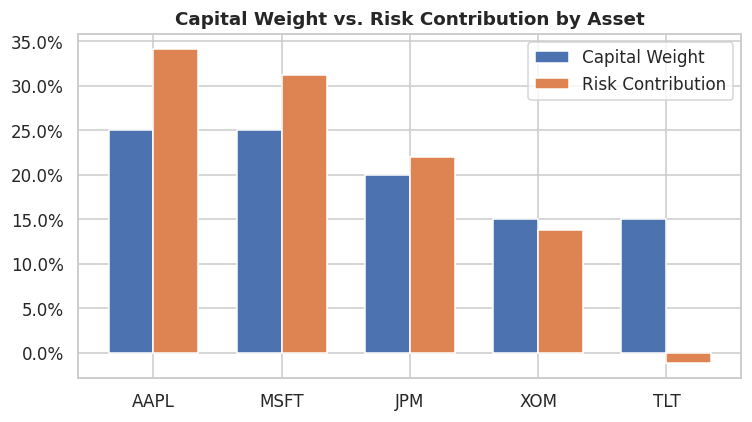

In [9]:
def risk_contribution(weights, cov_matrix):
    """
    Component risk contribution per asset: how much of total portfolio volatility
    each position is actually responsible for, not just its capital weight.
    """
    weights = np.asarray(weights)
    port_variance = weights @ cov_matrix @ weights
    port_vol = np.sqrt(port_variance)
    marginal_contrib = (cov_matrix @ weights) / port_vol
    component_contrib = weights * marginal_contrib
    pct_contrib = component_contrib / component_contrib.sum()
    return component_contrib, pct_contrib

component_contrib, pct_contrib = risk_contribution(weights, cov_matrix)

risk_contrib_df = pd.DataFrame({
    "Ticker": CONFIG["tickers"],
    "Capital Weight": weights,
    "Risk Contribution %": pct_contrib,
}).sort_values("Risk Contribution %", ascending=False)

print(risk_contrib_df.to_string(index=False, formatters={
    "Capital Weight": "{:.1%}".format,
    "Risk Contribution %": "{:.1%}".format,
}))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(CONFIG["tickers"]))
width = 0.35
ax.bar(x - width/2, risk_contrib_df["Capital Weight"], width, label="Capital Weight")
ax.bar(x + width/2, risk_contrib_df["Risk Contribution %"], width, label="Risk Contribution")
ax.set_xticks(x)
ax.set_xticklabels(risk_contrib_df["Ticker"])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Capital Weight vs. Risk Contribution by Asset")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
rows = []
for c in CONFIG["confidence_levels"]:
    rows.append({
        "Confidence": f"{int(c*100)}%",
        "Parametric VaR": parametric_results[c]["VaR"],
        "Parametric CVaR": parametric_results[c]["CVaR"],
        "Historical VaR": historical_results[c]["VaR"],
        "Historical CVaR": historical_results[c]["CVaR"],
        "Monte Carlo VaR": monte_carlo_results[c]["VaR"],
        "Monte Carlo CVaR": monte_carlo_results[c]["CVaR"],
    })

summary_df = pd.DataFrame(rows).set_index("Confidence")
# format for display; .apply() per column is used instead of the now-removed .applymap()
summary_df_display = summary_df.apply(lambda col: col.map(lambda x: f"${x:,.0f}"))
summary_df_display

,Parametric VaR,Parametric CVaR,Historical VaR,Historical CVaR,Monte Carlo VaR,Monte Carlo CVaR
Confidence,,,,,,
95%,"$189,978","$239,754","$177,410","$284,444","$191,693","$242,090"
99%,"$271,159","$311,525","$339,006","$490,125","$271,516","$310,840"


Backtest window: 1884 trading days
Observed breaches: 97  (expected ~94.2 at 95% confidence)
Kupiec LR statistic: 0.087   p-value: 0.768
Model PASSES the Kupiec test at the 5% significance level.


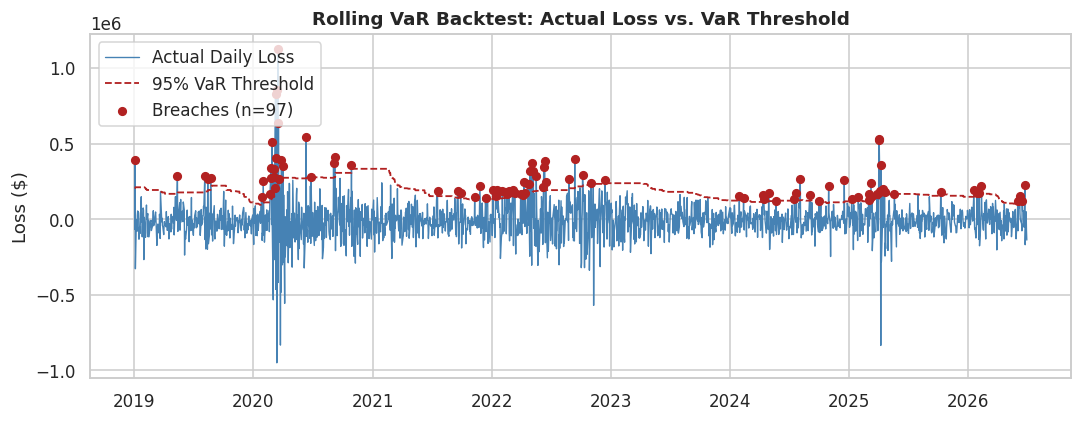

In [11]:
def rolling_var_backtest(returns_series, confidence, window, value, method="historical"):
    """
    Walk-forward VaR backtest: at each step, compute VaR from the trailing `window`
    of returns, then compare it to the actual realized loss the following day.
    """
    if len(returns_series) <= window:
        raise ValueError("returns_series must be longer than the backtest window")

    records = []
    for i in range(window, len(returns_series)):
        train = returns_series.iloc[i - window:i]
        actual_next_return = returns_series.iloc[i]
        if method == "historical":
            var, _ = historical_var_cvar(train, confidence, value)
        elif method == "parametric":
            var, _ = parametric_var_cvar(train.mean(), train.std(), confidence, value)
        else:
            raise ValueError("method must be 'historical' or 'parametric'")
        actual_loss = -actual_next_return * value
        records.append({
            "date": returns_series.index[i],
            "var": var,
            "actual_loss": actual_loss,
            "breach": actual_loss > var,
        })
    return pd.DataFrame(records).set_index("date")


def kupiec_pof_test(n_obs, n_breaches, confidence):
    """
    Kupiec (1995) proportion-of-failures likelihood-ratio test.
    Null hypothesis: the observed breach rate matches the model's stated (1-confidence)
    breach probability. p-value > 0.05 means we fail to reject the null, i.e. the model
    is statistically consistent with its stated confidence level.
    """
    p = 1 - confidence
    p_hat = n_breaches / n_obs
    p_hat_clipped = min(max(p_hat, 1e-6), 1 - 1e-6)  # avoid log(0)
    ll_null = (n_obs - n_breaches) * np.log(1 - p) + n_breaches * np.log(p)
    ll_alt = (n_obs - n_breaches) * np.log(1 - p_hat_clipped) + n_breaches * np.log(p_hat_clipped)
    lr_stat = -2 * (ll_null - ll_alt)
    p_value = 1 - stats.chi2.cdf(lr_stat, df=1)
    return lr_stat, p_value


backtest_df = rolling_var_backtest(
    portfolio_returns, CONFIG["backtest_confidence"], CONFIG["backtest_window"],
    CONFIG["portfolio_value"], method="historical"
)

n_obs = len(backtest_df)
n_breaches = int(backtest_df["breach"].sum())
expected_breaches = (1 - CONFIG["backtest_confidence"]) * n_obs
lr_stat, p_value = kupiec_pof_test(n_obs, n_breaches, CONFIG["backtest_confidence"])

print(f"Backtest window: {n_obs} trading days")
print(f"Observed breaches: {n_breaches}  (expected ~{expected_breaches:.1f} "
      f"at {int(CONFIG['backtest_confidence']*100)}% confidence)")
print(f"Kupiec LR statistic: {lr_stat:.3f}   p-value: {p_value:.3f}")
print(f"Model {'PASSES' if p_value > 0.05 else 'FAILS'} the Kupiec test at the 5% significance level.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(backtest_df.index, backtest_df["actual_loss"], color="steelblue",
        linewidth=0.9, label="Actual Daily Loss")
ax.plot(backtest_df.index, backtest_df["var"], color="firebrick",
        linewidth=1.2, linestyle="--", label=f"{int(CONFIG['backtest_confidence']*100)}% VaR Threshold")
breach_points = backtest_df[backtest_df["breach"]]
ax.scatter(breach_points.index, breach_points["actual_loss"], color="firebrick",
           zorder=5, s=25, label=f"Breaches (n={n_breaches})")
ax.set_title("Rolling VaR Backtest: Actual Loss vs. VaR Threshold")
ax.set_ylabel("Loss ($)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

                             VaR_95     CVaR_95 Multiple of Baseline VaR
Scenario                                                                
Baseline                   $191,693    $242,090                    1.00x
2008-style (GFC)           $801,089    $980,042                    4.18x
2020-style (COVID)       $1,165,595  $1,409,489                    6.08x
2022-style (Rate Shock)    $428,568    $526,317                    2.24x


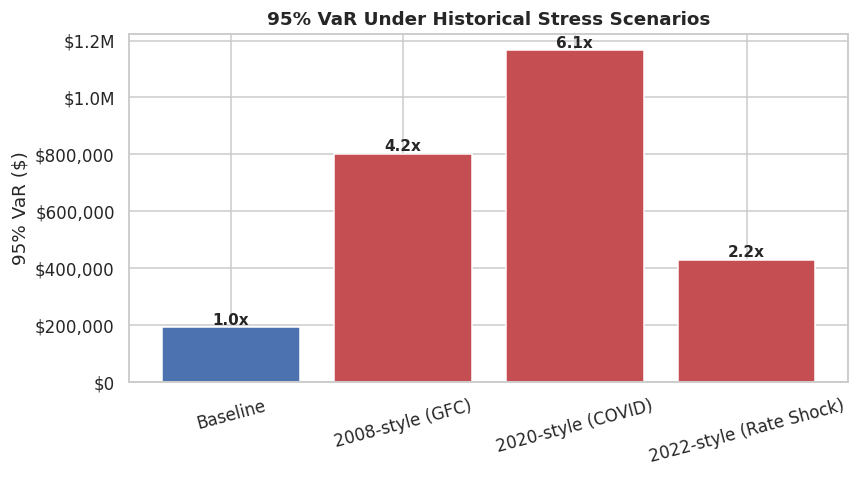

In [12]:
def apply_stress_scenario(mean_vec, cov_matrix, vol_multiplier=1.0, corr_add=0.0, mean_shock=0.0):
    """
    Apply a stress scenario by scaling volatility, pushing correlations toward 1,
    and shocking the mean return -- the three things that move together in a real crisis.
    """
    n = len(mean_vec)
    std = np.sqrt(np.diag(cov_matrix))
    corr = cov_matrix / np.outer(std, std)

    off_diag_mask = 1 - np.eye(n)
    stressed_corr = np.clip(corr + corr_add * off_diag_mask, -0.99, 0.99)
    np.fill_diagonal(stressed_corr, 1.0)

    stressed_std = std * vol_multiplier
    stressed_cov = np.outer(stressed_std, stressed_std) * stressed_corr
    stressed_mean = mean_vec + mean_shock
    return stressed_mean, stressed_cov


# Illustrative shocks, not a precise historical replay -- calibrated to be directionally
# realistic (vol multiples and correlation increases observed in past crises).
STRESS_SCENARIOS = {
    "Baseline":               dict(vol_multiplier=1.0, corr_add=0.00, mean_shock=0.000),
    "2008-style (GFC)":       dict(vol_multiplier=3.0, corr_add=0.25, mean_shock=-0.010),
    "2020-style (COVID)":     dict(vol_multiplier=4.0, corr_add=0.30, mean_shock=-0.020),
    "2022-style (Rate Shock)":dict(vol_multiplier=1.8, corr_add=0.10, mean_shock=-0.005),
}

stress_records = []
for name, params in STRESS_SCENARIOS.items():
    s_mean, s_cov = apply_stress_scenario(mean_vec, cov_matrix, **params)
    s_engine = MonteCarloVaREngine(s_mean, s_cov, weights, CONFIG["portfolio_value"], seed=CONFIG["random_seed"])
    var95, cvar95 = s_engine.var_cvar(0.95, n_sims=CONFIG["n_simulations"])
    stress_records.append({"Scenario": name, "VaR_95": var95, "CVaR_95": cvar95})

stress_df = pd.DataFrame(stress_records).set_index("Scenario")
baseline_var = stress_df.loc["Baseline", "VaR_95"]
stress_df["Multiple of Baseline VaR"] = stress_df["VaR_95"] / baseline_var

stress_df_display = stress_df.copy()
stress_df_display["VaR_95"] = stress_df_display["VaR_95"].map(lambda x: f"${x:,.0f}")
stress_df_display["CVaR_95"] = stress_df_display["CVaR_95"].map(lambda x: f"${x:,.0f}")
stress_df_display["Multiple of Baseline VaR"] = stress_df_display["Multiple of Baseline VaR"].map(lambda x: f"{x:.2f}x")
print(stress_df_display)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#4C72B0", "#C44E52", "#C44E52", "#C44E52"]
bars = ax.bar(stress_df.index, stress_df["VaR_95"], color=colors[:len(stress_df)])
ax.set_ylabel("95% VaR ($)")
ax.set_title("95% VaR Under Historical Stress Scenarios")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x:,.0f}"))
for bar, val in zip(bars, stress_df["Multiple of Baseline VaR"]):
    ax.annotate(f"{val:.1f}x", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

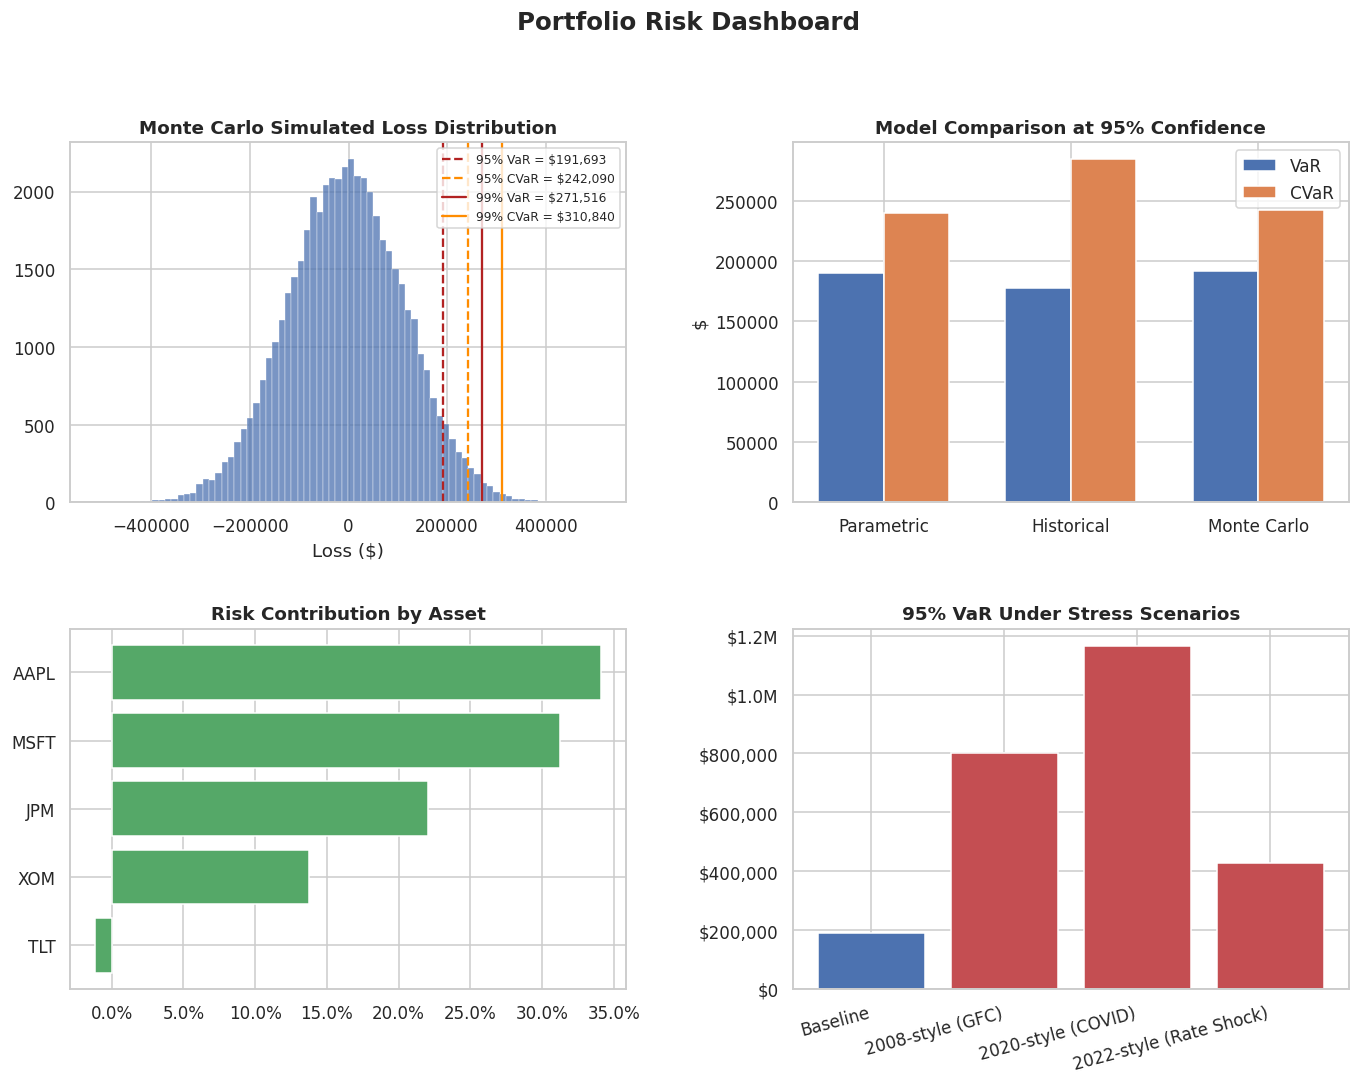

In [13]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# --- Panel 1: Simulated P&L distribution with VaR/CVaR lines ---
ax1 = fig.add_subplot(gs[0, 0])
losses = -sim_pnl_distribution
ax1.hist(losses, bins=80, color="#4C72B0", alpha=0.75, edgecolor="white", linewidth=0.3)
for c, style in zip(CONFIG["confidence_levels"], ["--", "-"]):
    var = monte_carlo_results[c]["VaR"]
    cvar = monte_carlo_results[c]["CVaR"]
    ax1.axvline(var, color="firebrick", linestyle=style, linewidth=1.5,
                label=f"{int(c*100)}% VaR = ${var:,.0f}")
    ax1.axvline(cvar, color="darkorange", linestyle=style, linewidth=1.5,
                label=f"{int(c*100)}% CVaR = ${cvar:,.0f}")
ax1.set_title("Monte Carlo Simulated Loss Distribution")
ax1.set_xlabel("Loss ($)")
ax1.legend(fontsize=8, loc="upper right")

# --- Panel 2: Model comparison ---
ax2 = fig.add_subplot(gs[0, 1])
methods = ["Parametric", "Historical", "Monte Carlo"]
c_main = CONFIG["confidence_levels"][0]
var_vals = [parametric_results[c_main]["VaR"], historical_results[c_main]["VaR"], monte_carlo_results[c_main]["VaR"]]
cvar_vals = [parametric_results[c_main]["CVaR"], historical_results[c_main]["CVaR"], monte_carlo_results[c_main]["CVaR"]]
x = np.arange(len(methods))
width = 0.35
ax2.bar(x - width/2, var_vals, width, label="VaR", color="#4C72B0")
ax2.bar(x + width/2, cvar_vals, width, label="CVaR", color="#DD8452")
ax2.set_xticks(x)
ax2.set_xticklabels(methods)
ax2.set_title(f"Model Comparison at {int(c_main*100)}% Confidence")
ax2.set_ylabel("$")
ax2.legend()

# --- Panel 3: Risk contribution ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.barh(risk_contrib_df["Ticker"], risk_contrib_df["Risk Contribution %"], color="#55A868")
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax3.set_title("Risk Contribution by Asset")
ax3.invert_yaxis()

# --- Panel 4: Stress scenarios ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(stress_df.index, stress_df["VaR_95"], color=["#4C72B0", "#C44E52", "#C44E52", "#C44E52"][:len(stress_df)])
ax4.set_title("95% VaR Under Stress Scenarios")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x:,.0f}"))
plt.setp(ax4.get_xticklabels(), rotation=15, ha="right")

fig.suptitle("Portfolio Risk Dashboard", fontsize=16, fontweight="bold", y=1.0)
plt.show()

In [14]:
report_lines = []
report_lines.append("=" * 62)
report_lines.append("PORTFOLIO RISK REPORT")
report_lines.append("=" * 62)
report_lines.append(f"Portfolio:        {dict(zip(CONFIG['tickers'], np.round(CONFIG['weights'], 3)))}")
report_lines.append(f"Notional value:   ${CONFIG['portfolio_value']:,.0f}")
report_lines.append(f"Sample period:    {log_returns.index[0].date()} to {log_returns.index[-1].date()}")
report_lines.append(f"Horizon:          {CONFIG['horizon_days']}-day VaR/CVaR")
report_lines.append("-" * 62)
for c in CONFIG["confidence_levels"]:
    report_lines.append(f"\n{int(c*100)}% Confidence Level:")
    report_lines.append(f"  Parametric   VaR: ${parametric_results[c]['VaR']:>12,.0f}   CVaR: ${parametric_results[c]['CVaR']:>12,.0f}")
    report_lines.append(f"  Historical   VaR: ${historical_results[c]['VaR']:>12,.0f}   CVaR: ${historical_results[c]['CVaR']:>12,.0f}")
    report_lines.append(f"  Monte Carlo  VaR: ${monte_carlo_results[c]['VaR']:>12,.0f}   CVaR: ${monte_carlo_results[c]['CVaR']:>12,.0f}")
report_lines.append("-" * 62)
report_lines.append(f"\nBacktest ({CONFIG['backtest_confidence']:.0%} VaR, {CONFIG['backtest_window']}-day rolling window):")
report_lines.append(f"  {n_breaches} breaches in {n_obs} days (expected ~{expected_breaches:.1f})")
report_lines.append(f"  Kupiec test: LR={lr_stat:.3f}, p-value={p_value:.3f} "
                     f"({'PASS' if p_value > 0.05 else 'FAIL'})")
report_lines.append("-" * 62)
report_lines.append("\nStress Test Summary (95% VaR):")
for scenario, row in stress_df.iterrows():
    report_lines.append(f"  {scenario:<26} ${row['VaR_95']:>12,.0f}   ({row['Multiple of Baseline VaR']:.1f}x baseline)")
report_lines.append("-" * 62)
report_lines.append("\nTop Risk Contributors:")
for _, row in risk_contrib_df.head(3).iterrows():
    report_lines.append(f"  {row['Ticker']:<8} contributes {row['Risk Contribution %']:.1%} of total risk "
                         f"(capital weight: {row['Capital Weight']:.1%})")
report_lines.append("=" * 62)

report_text = "\n".join(report_lines)
print(report_text)

# Export to CSV -- wrapped in try/except so a read-only or missing directory doesn't crash the run
try:
    summary_df.to_csv("var_summary.csv")
    backtest_df.to_csv("backtest_results.csv")
    stress_df.to_csv("stress_test_results.csv")
    with open("risk_report.txt", "w") as f:
        f.write(report_text)
    print("\nExported: var_summary.csv, backtest_results.csv, stress_test_results.csv, risk_report.txt")
except OSError as e:
    print(f"\nCould not write output files: {e}")

PORTFOLIO RISK REPORT
Portfolio:        {'AAPL': np.float64(0.25), 'MSFT': np.float64(0.25), 'JPM': np.float64(0.2), 'XOM': np.float64(0.15), 'TLT': np.float64(0.15)}
Notional value:   $10,000,000
Sample period:    2018-01-03 to 2026-07-01
Horizon:          1-day VaR/CVaR
--------------------------------------------------------------

95% Confidence Level:
  Parametric   VaR: $     189,978   CVaR: $     239,754
  Historical   VaR: $     177,410   CVaR: $     284,444
  Monte Carlo  VaR: $     191,693   CVaR: $     242,090

99% Confidence Level:
  Parametric   VaR: $     271,159   CVaR: $     311,525
  Historical   VaR: $     339,006   CVaR: $     490,125
  Monte Carlo  VaR: $     271,516   CVaR: $     310,840
--------------------------------------------------------------

Backtest (95% VaR, 250-day rolling window):
  97 breaches in 1884 days (expected ~94.2)
  Kupiec test: LR=0.087, p-value=0.768 (PASS)
--------------------------------------------------------------

Stress Test Summary 

In [15]:
from matplotlib.patches import Wedge
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────────────────────────────
# Risk Health Score Engine
#
# All six dimensions are scored from quantitative outputs already
# computed above — no new data, no new API calls.
# Weights are calibrated to match how institutional risk desks
# actually prioritize these metrics:
#   Return Quality     25 pts  (Sharpe — are you being compensated for risk?)
#   Drawdown Control   20 pts  (max drawdown — survivability)
#   Tail Risk          20 pts  (CVaR99 % of notional — extreme loss exposure)
#   Model Validity     15 pts  (Kupiec test — does the model know itself?)
#   Stress Resilience  15 pts  (crisis VaR multiple — crisis-proofing)
#   Concentration       5 pts  (max risk contribution — single-name risk)
# ─────────────────────────────────────────────────────────────────────

COMPONENT_MAX = {
    "Return Quality":    25,
    "Drawdown Control":  20,
    "Tail Risk":         20,
    "Model Validity":    15,
    "Stress Resilience": 15,
    "Concentration":      5,
}

def compute_portfolio_max_drawdown(returns_series):
    """
    Maximum peak-to-trough drawdown from a log-return series.
    Returns a negative float, e.g. -0.18 for an 18% drawdown.
    """
    wealth = (1 + returns_series).cumprod()
    return float(((wealth - wealth.cummax()) / wealth.cummax()).min())


def compute_risk_health_score(
    annualized_sharpe,
    max_drawdown,            # negative fraction, e.g. -0.15
    cvar99_pct,              # 99% CVaR as fraction of portfolio value (positive)
    kupiec_pass,             # bool: Kupiec p-value > 0.05
    breach_rate,             # n_breach / n_obs from rolling backtest
    expected_breach_rate,    # 1 - backtest_confidence
    worst_stress_multiple,   # worst-case stress VaR / baseline VaR
    max_risk_contrib_pct,    # max single-asset risk contribution (fraction)
):
    """
    Score a strategy's risk profile across six dimensions.
    Returns (total_score: int, component_scores: dict).
    """
    s = {}

    # ── 1. Return Quality (25 pts) ─────────────────────────────────────
    # Annualized Sharpe ratio measures return per unit of volatility taken.
    # Threshold: >1.0 is acceptable, >1.5 is strong, >2.0 is excellent.
    if annualized_sharpe >= 2.0:   s["Return Quality"] = 25
    elif annualized_sharpe >= 1.5: s["Return Quality"] = 20
    elif annualized_sharpe >= 1.0: s["Return Quality"] = 15
    elif annualized_sharpe >= 0.5: s["Return Quality"] = 8
    else:                           s["Return Quality"] = 3

    # ── 2. Drawdown Control (20 pts) ───────────────────────────────────
    # Max drawdown is the largest single loss a real user would have
    # experienced — the metric that drives redemptions and stops live bots.
    md = abs(max_drawdown)
    if md < 0.05:   s["Drawdown Control"] = 20
    elif md < 0.10: s["Drawdown Control"] = 16
    elif md < 0.15: s["Drawdown Control"] = 12
    elif md < 0.25: s["Drawdown Control"] = 7
    else:            s["Drawdown Control"] = 3

    # ── 3. Tail Risk (20 pts) ──────────────────────────────────────────
    # CVaR99 as % of notional captures the expected loss beyond the 99%
    # threshold — the metric Basel III uses because it penalizes fat tails.
    if cvar99_pct < 0.010:  s["Tail Risk"] = 20
    elif cvar99_pct < 0.020: s["Tail Risk"] = 16
    elif cvar99_pct < 0.030: s["Tail Risk"] = 12
    elif cvar99_pct < 0.050: s["Tail Risk"] = 7
    else:                     s["Tail Risk"] = 3

    # ── 4. Model Validity (15 pts) ─────────────────────────────────────
    # A model that overstates accuracy is worse than one that admits
    # uncertainty. Kupiec test confirms the breach rate matches the
    # stated confidence level.
    if kupiec_pass:
        acc = abs(breach_rate - expected_breach_rate) / max(expected_breach_rate, 1e-9)
        if acc < 0.20:   s["Model Validity"] = 15
        elif acc < 0.40: s["Model Validity"] = 12
        else:             s["Model Validity"] = 9
    else:
        s["Model Validity"] = 3

    # ── 5. Stress Resilience (15 pts) ──────────────────────────────────
    # How many times larger does VaR get when you apply historical crisis
    # conditions? A 4x+ multiple means the strategy wasn't designed for
    # the conditions that actually matter most.
    if worst_stress_multiple < 2.0:   s["Stress Resilience"] = 15
    elif worst_stress_multiple < 3.0: s["Stress Resilience"] = 12
    elif worst_stress_multiple < 4.0: s["Stress Resilience"] = 8
    elif worst_stress_multiple < 6.0: s["Stress Resilience"] = 4
    else:                              s["Stress Resilience"] = 1

    # ── 6. Concentration Risk (5 pts) ──────────────────────────────────
    # If one asset drives more than 40% of total portfolio variance,
    # you're not really diversified regardless of how many positions you hold.
    if max_risk_contrib_pct < 0.30:   s["Concentration"] = 5
    elif max_risk_contrib_pct < 0.40: s["Concentration"] = 3
    else:                              s["Concentration"] = 1

    return sum(s.values()), s


def score_to_grade(score):
    """Map 0-100 health score to a letter grade and its hex color."""
    if score >= 90: return "A+", "#16a34a"
    if score >= 80: return "A",  "#22c55e"
    if score >= 70: return "B+", "#65a30d"
    if score >= 60: return "B",  "#ca8a04"
    if score >= 50: return "C",  "#ea580c"
    return            "D",       "#dc2626"


def generate_insights(
    annualized_sharpe, max_drawdown, cvar99_pct, kupiec_pass,
    worst_stress_multiple, max_risk_contrib_pct, top_risk_asset,
    annualized_return, component_scores,
):
    """
    Generate rule-based strengths, weaknesses, and suggestions
    directly from the quantitative outputs — no LLM required.
    Returns three lists capped at 4 items each.
    """
    md = abs(max_drawdown)
    strengths, weaknesses, suggestions = [], [], []

    # ── Strengths ──────────────────────────────────────────────────────
    if component_scores["Return Quality"] >= 20:
        strengths.append(f"Strong risk-adjusted returns (Sharpe: {annualized_sharpe:.2f})")
    elif component_scores["Return Quality"] >= 15:
        strengths.append(f"Acceptable risk-adjusted returns (Sharpe: {annualized_sharpe:.2f})")
    if component_scores["Drawdown Control"] >= 16:
        strengths.append(f"Disciplined drawdown control (max {md:.1%})")
    if kupiec_pass:
        strengths.append("VaR model statistically well-calibrated (Kupiec: pass)")
    if component_scores["Concentration"] == 5:
        strengths.append("Low concentration — diversified risk allocation")
    if component_scores["Stress Resilience"] >= 12:
        strengths.append("Resilient to historical crisis scenarios")
    if annualized_return > 0.10:
        strengths.append(f"Positive annualized return ({annualized_return:.1%})")
    if not strengths:
        strengths.append("Strategy tested against real historical return data")

    # ── Weaknesses ─────────────────────────────────────────────────────
    if component_scores["Return Quality"] <= 8:
        weaknesses.append(f"Low risk-adjusted returns (Sharpe: {annualized_sharpe:.2f})")
    if md > 0.20:
        weaknesses.append(f"Significant drawdown exposure (max {md:.1%})")
    elif md > 0.10:
        weaknesses.append(f"Moderate drawdown risk ({md:.1%})")
    if component_scores["Tail Risk"] <= 7:
        weaknesses.append(f"Heavy tail — 99% CVaR is {cvar99_pct:.1%} of notional")
    if worst_stress_multiple > 4.0:
        weaknesses.append(f"High volatility sensitivity ({worst_stress_multiple:.1f}x VaR under stress)")
    if not kupiec_pass:
        weaknesses.append("VaR model under-calibrated — breach rate above expected")
    if max_risk_contrib_pct > 0.40:
        weaknesses.append(
            f"Concentrated risk: {top_risk_asset} drives {max_risk_contrib_pct:.0%} of total variance"
        )
    if not weaknesses:
        weaknesses.append("Minor refinements could improve risk-adjusted performance")

    # ── Suggestions ────────────────────────────────────────────────────
    if max_risk_contrib_pct > 0.35:
        suggestions.append(
            f"Reduce {top_risk_asset} — currently {max_risk_contrib_pct:.0%} of risk budget"
        )
    if worst_stress_multiple > 3.0:
        suggestions.append("Add VIX-based position sizing: cut exposure when VIX > 25")
    if md > 0.15:
        suggestions.append("Introduce a max-drawdown circuit breaker or trailing stop")
    if component_scores["Return Quality"] <= 8:
        suggestions.append("Review entry/exit logic — add a momentum or trend-strength filter")
    if not kupiec_pass:
        suggestions.append("Switch to Student-t innovations to better capture fat tails")
    if component_scores["Concentration"] <= 3:
        suggestions.append("Add bonds or gold to reduce single-name risk concentration")
    if component_scores["Stress Resilience"] <= 4:
        suggestions.append("Consider regime-aware sizing: scale down when vol regime is elevated")
    if not suggestions:
        suggestions.append("Risk profile looks solid — continue weekly deployment monitoring")

    return strengths[:4], weaknesses[:4], suggestions[:4]


print("Risk Health Score engine loaded.")


Risk Health Score engine loaded.


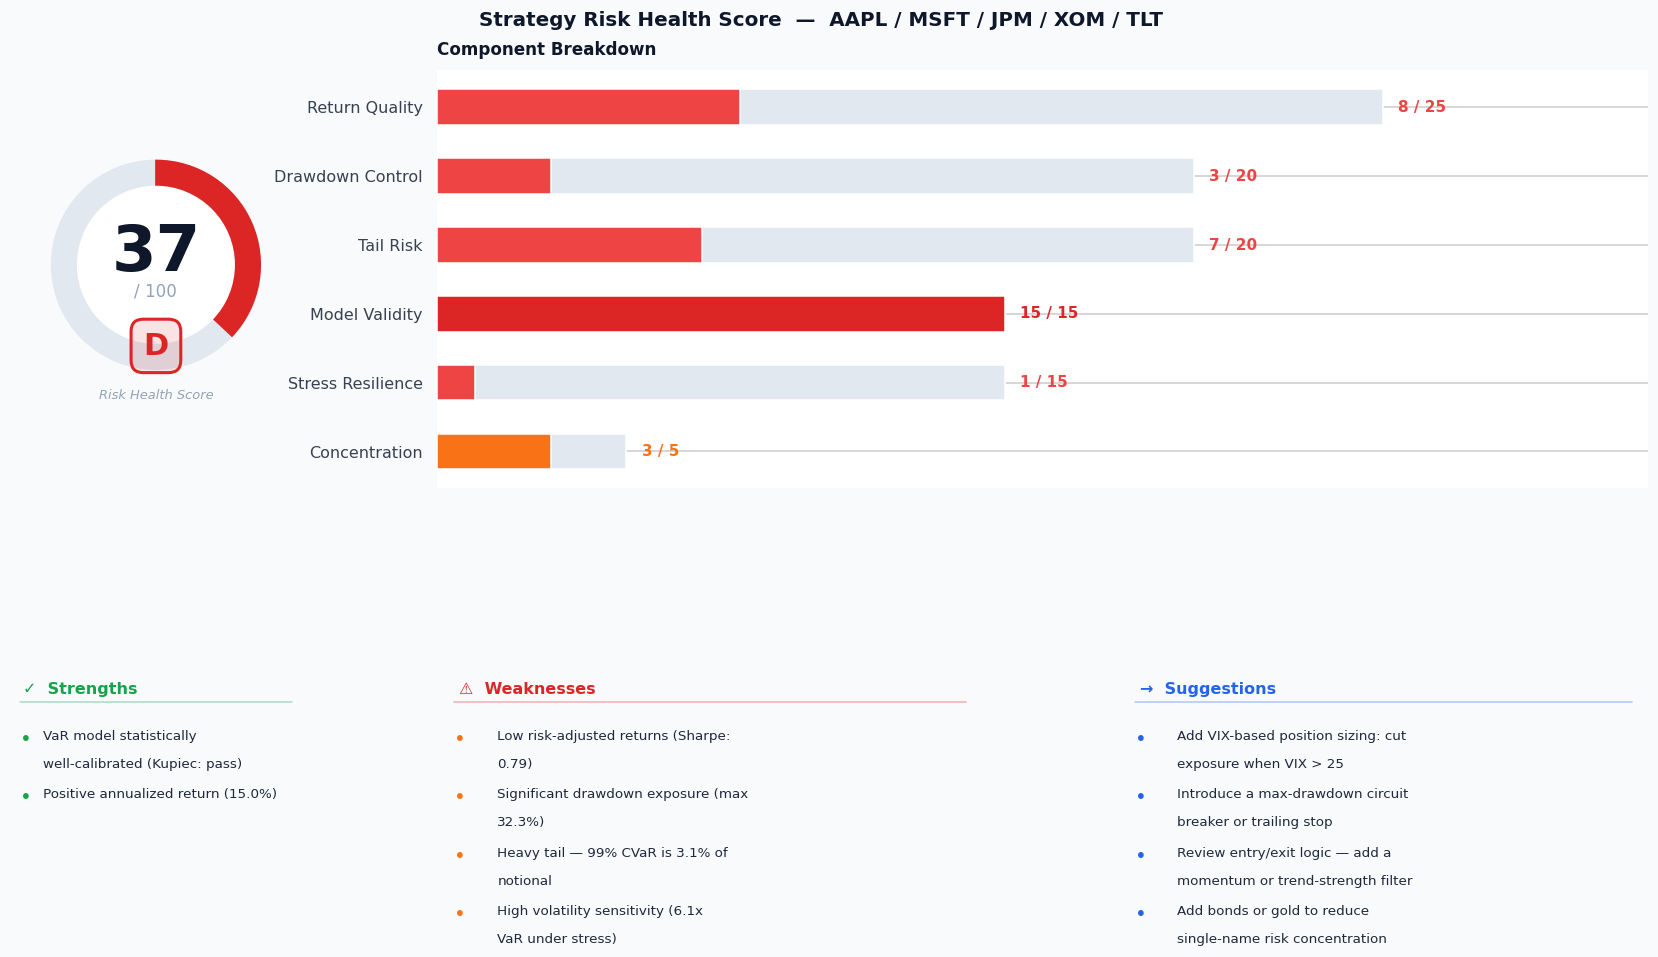


────────────────────────────────────────────────────
  Strategy Health: 37/100  [D]
────────────────────────────────────────────────────

Component Scores
  Return Quality        ██████░░░░░░░░░░░░   8/25
  Drawdown Control      ███░░░░░░░░░░░░░░░   3/20
  Tail Risk             ██████░░░░░░░░░░░░   7/20
  Model Validity        ██████████████████  15/15
  Stress Resilience     █░░░░░░░░░░░░░░░░░   1/15
  Concentration         ███████████░░░░░░░   3/5

Strengths
  ✓ VaR model statistically well-calibrated (Kupiec: pass)
  ✓ Positive annualized return (15.0%)

Weaknesses
  • Low risk-adjusted returns (Sharpe: 0.79)
  • Significant drawdown exposure (max 32.3%)
  • Heavy tail — 99% CVaR is 3.1% of notional
  • High volatility sensitivity (6.1x VaR under stress)

Suggestions
  → Add VIX-based position sizing: cut exposure when VIX > 25
  → Introduce a max-drawdown circuit breaker or trailing stop
  → Review entry/exit logic — add a momentum or trend-strength filter
  → Add bonds or gold to

In [16]:
# ─────────────────────────────────────────────────────────────────────
# Compute Risk Health Score from existing notebook variables
# then render the full dashboard card and text report.
# ─────────────────────────────────────────────────────────────────────

# ── 1. Derive inputs from variables already computed above ────────────

annualized_sharpe_val    = (mu_p * np.sqrt(252)) / sigma_p
max_drawdown_val         = compute_portfolio_max_drawdown(portfolio_returns)
cvar99_pct_val           = monte_carlo_results[0.99]["CVaR"] / CONFIG["portfolio_value"]
kupiec_pass_val          = p_value > 0.05
breach_rate_val          = n_breaches / n_obs
expected_breach_rate_val = 1.0 - CONFIG["backtest_confidence"]

# Worst-case stress multiple, excluding the Baseline row
non_baseline = stress_df.loc[stress_df.index != "Baseline", "Multiple of Baseline VaR"]
worst_stress_multiple_val = float(non_baseline.max())

top_risk_idx          = int(np.argmax(pct_contrib))
max_risk_contrib_val  = float(pct_contrib[top_risk_idx])
top_risk_asset_val    = CONFIG["tickers"][top_risk_idx]
annualized_return_val = mu_p * 252

# ── 2. Score ──────────────────────────────────────────────────────────

health_score, component_scores = compute_risk_health_score(
    annualized_sharpe_val, max_drawdown_val, cvar99_pct_val,
    kupiec_pass_val, breach_rate_val, expected_breach_rate_val,
    worst_stress_multiple_val, max_risk_contrib_val,
)
grade, grade_color = score_to_grade(health_score)

# ── 3. Generate insights ──────────────────────────────────────────────

strengths, weaknesses, suggestions = generate_insights(
    annualized_sharpe_val, max_drawdown_val, cvar99_pct_val,
    kupiec_pass_val, worst_stress_multiple_val, max_risk_contrib_val,
    top_risk_asset_val, annualized_return_val, component_scores,
)

# ── 4. Render visual dashboard card ──────────────────────────────────

# Color constants — consistent with a Mobius-style dark/light UI
CARD_BG       = "#f8fafc"
PANEL_BG      = "white"
TEXT_DARK     = "#0f172a"
TEXT_MID      = "#475569"
TEXT_LIGHT    = "#94a3b8"
TRACK_COLOR   = "#e2e8f0"
GREEN         = "#16a34a"
ORANGE        = "#f97316"
RED_WEAK      = "#dc2626"
BLUE_SUG      = "#2563eb"

def _bar_color(earned, maximum):
    """Color a component bar green/amber/red by its pct of max."""
    pct = earned / maximum
    if pct >= 0.75: return grade_color
    if pct >= 0.50: return "#f97316"
    return "#ef4444"

fig = plt.figure(figsize=(16, 9), facecolor=CARD_BG)
fig.suptitle(
    f"Strategy Risk Health Score  —  {' / '.join(CONFIG['tickers'])}",
    fontsize=13, fontweight="bold", color=TEXT_DARK, y=0.98,
)

gs = GridSpec(
    2, 3, figure=fig,
    height_ratios=[1.5, 1],
    width_ratios=[0.85, 1.6, 1.55],
    hspace=0.50, wspace=0.30,
    left=0.04, right=0.97, top=0.92, bottom=0.04,
)

# ── Panel A: Score gauge ──────────────────────────────────────────────
ax_g = fig.add_subplot(gs[0, 0])
ax_g.set_xlim(0, 1)
ax_g.set_ylim(0, 1)
ax_g.set_aspect("equal")
ax_g.axis("off")
ax_g.set_facecolor(PANEL_BG)
for spine in ax_g.spines.values():
    spine.set_visible(False)

# Track ring (grey)
ax_g.add_patch(Wedge((0.5, 0.55), 0.36, 0, 360, width=0.09,
                      color=TRACK_COLOR, zorder=1))

# Filled arc — clockwise from the top.
# Wedge goes counterclockwise; starting at (90 - angle) and ending at 90
# gives us a clockwise-looking fill of `angle` degrees starting from the top.
arc_angle = (health_score / 100) * 360
ax_g.add_patch(Wedge((0.5, 0.55), 0.36, 90 - arc_angle, 90,
                      width=0.09, color=grade_color, zorder=2))

# Inner white disc (donut hole)
ax_g.add_patch(plt.Circle((0.5, 0.55), 0.27, color=PANEL_BG, zorder=3))

# Score number + /100
ax_g.text(0.5, 0.59, str(health_score),
          ha="center", va="center", fontsize=42, fontweight="bold",
          color=TEXT_DARK, zorder=4, transform=ax_g.transAxes)
ax_g.text(0.5, 0.46, "/ 100",
          ha="center", va="center", fontsize=11, color=TEXT_LIGHT,
          zorder=4, transform=ax_g.transAxes)

# Grade badge
ax_g.text(0.5, 0.27, grade,
          ha="center", va="center", fontsize=20, fontweight="bold",
          color=grade_color, zorder=4, transform=ax_g.transAxes,
          bbox=dict(boxstyle="round,pad=0.4",
                    facecolor=grade_color + "20",
                    edgecolor=grade_color, linewidth=2.0))

ax_g.text(0.5, 0.10, "Risk Health Score",
          ha="center", va="center", fontsize=8.5,
          color=TEXT_LIGHT, style="italic", transform=ax_g.transAxes)

# ── Panel B: Component bars ───────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1:])
ax_b.set_facecolor(PANEL_BG)
for sp in ax_b.spines.values():
    sp.set_visible(False)
ax_b.tick_params(left=False, bottom=False)

components = list(component_scores.keys())
earned_pts = [component_scores[c] for c in components]
max_pts    = [COMPONENT_MAX[c] for c in components]
y_pos      = np.arange(len(components))

# Background bars (max width)
ax_b.barh(y_pos, max_pts, height=0.52, color=TRACK_COLOR, zorder=1)
# Filled bars (earned width)
bar_colors = [_bar_color(e, m) for e, m in zip(earned_pts, max_pts)]
ax_b.barh(y_pos, earned_pts, height=0.52, color=bar_colors, zorder=2)

ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(components, fontsize=10.5, color="#374151")
ax_b.set_xticks([])
ax_b.set_xlim(0, max(max_pts) * 1.28)
ax_b.invert_yaxis()

# Score labels after each bar
for i, (e, m) in enumerate(zip(earned_pts, max_pts)):
    pct = e / m
    col = bar_colors[i]
    ax_b.text(m + 0.4, i, f"{e} / {m}",
              va="center", ha="left", fontsize=10, color=col, fontweight="bold")

ax_b.set_title("Component Breakdown", fontsize=11, fontweight="bold",
               color=TEXT_DARK, pad=10, loc="left")

# ── Insight panels (Strengths / Weaknesses / Suggestions) ────────────

def render_insight_panel(ax, title, icon, title_color, bullet_color, items):
    ax.set_facecolor(PANEL_BG)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Title row
    ax.text(0.04, 0.93, f"{icon}  {title}",
            fontsize=10.5, fontweight="bold", color=title_color,
            va="top", transform=ax.transAxes)
    ax.axhline(y=0.86, xmin=0.03, xmax=0.97, color=title_color,
               linewidth=1.0, alpha=0.35)

    # Bullet items — simple word-wrap at ~38 chars
    for i, item in enumerate(items):
        y_base = 0.76 - i * 0.21
        ax.text(0.03, y_base, "•", fontsize=13, color=bullet_color,
                va="top", transform=ax.transAxes)
        words = item.split()
        lines, cur = [], []
        for w in words:
            cur.append(w)
            if len(" ".join(cur)) > 36:
                lines.append(" ".join(cur[:-1]))
                cur = [w]
        lines.append(" ".join(cur))
        for j, ln in enumerate(lines[:2]):
            ax.text(0.11, y_base - j * 0.10, ln,
                    fontsize=8.8, color="#1e293b",
                    va="top", transform=ax.transAxes)

ax_s = fig.add_subplot(gs[1, 0])
ax_w = fig.add_subplot(gs[1, 1])
ax_u = fig.add_subplot(gs[1, 2])

render_insight_panel(ax_s, "Strengths",   "✓", GREEN,    GREEN,    strengths)
render_insight_panel(ax_w, "Weaknesses",  "⚠", RED_WEAK, ORANGE,   weaknesses)
render_insight_panel(ax_u, "Suggestions", "→", BLUE_SUG, BLUE_SUG, suggestions)

plt.show()

# ── 5. Print clean text version (copy-paste ready for a pitch deck) ───

SEP = "─" * 52
print(f"\n{SEP}")
print(f"  Strategy Health: {health_score}/100  [{grade}]")
print(SEP)
print("\nComponent Scores")
for comp, pts in component_scores.items():
    mxp   = COMPONENT_MAX[comp]
    filled = int(round((pts / mxp) * 18))
    bar   = "█" * filled + "░" * (18 - filled)
    print(f"  {comp:<20}  {bar}  {pts:>2}/{mxp}")

print("\nStrengths")
for s in strengths:
    print(f"  ✓ {s}")

print("\nWeaknesses")
for w in weaknesses:
    print(f"  • {w}")

print("\nSuggestions")
for sg in suggestions:
    print(f"  → {sg}")

print(f"\n{SEP}\n")
